# Identify normal and abnormal human behavior using clustering techniques.

In [26]:
import pandas as pd
data = pd.read_csv("crowd_data.csv")
print(data.head())
print(data.describe())

   speed  time_spent  visits
0    1.2          10       3
1    1.5          12       4
2    2.0           8       2
3    1.8          15       5
4    2.2           9       3
           speed  time_spent      visits
count  100.00000  100.000000  100.000000
mean     5.29200   26.560000   11.280000
std      2.43869   17.236513    5.144537
min      1.00000    5.000000    2.000000
25%      3.37500   11.000000    7.000000
50%      5.40000   23.000000   11.500000
75%      7.32500   40.250000   14.250000
max      9.50000   60.000000   20.000000


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# K find

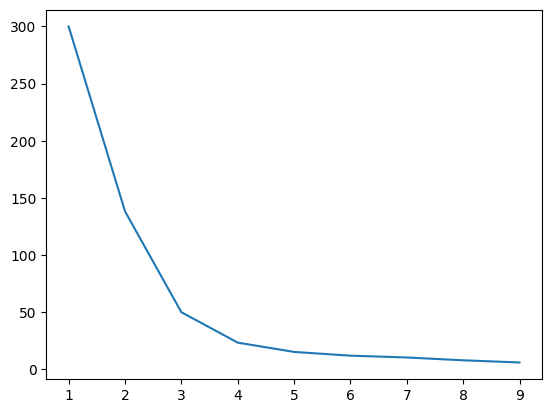

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for i in range(1,10):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.show()

In [19]:
kmeans = KMeans(n_clusters=3)
data['cluster'] = kmeans.fit_predict(X_scaled)

# DBSCAN

In [20]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps = 0.5,min_samples=5)
data['dbscan'] = db.fit_predict(X_scaled)

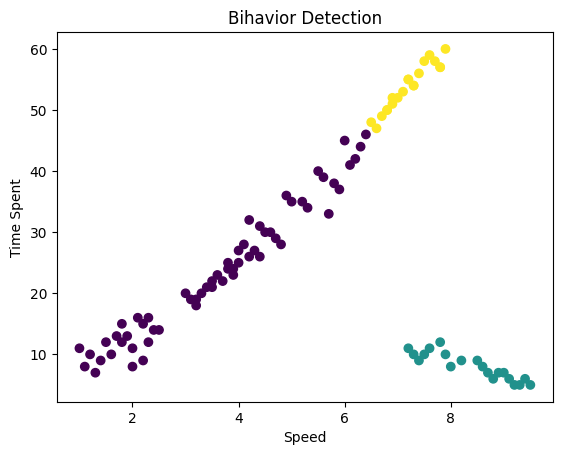

In [21]:
import matplotlib.pyplot as plt
plt.scatter(data['speed'],data['time_spent'],c = data['dbscan'])
plt.xlabel('Speed')
plt.ylabel('Time Spent')
plt.title("Bihavior Detection")
plt.show()

- Cluster groups = normal behavior
- DBSCAN = abnormal detection
- Outliers = suspicious users

In [22]:
data['behavior'] = data['cluster'].map({
    0: "Low Activity",
    1: "Normal",
    2: "High Activity"
})

In [23]:
outliers = data[data['dbscan'] == -1]
print("Suspicious Users:\n", outliers)

Suspicious Users:
 Empty DataFrame
Columns: [speed, time_spent, visits, cluster, dbscan, behavior]
Index: []


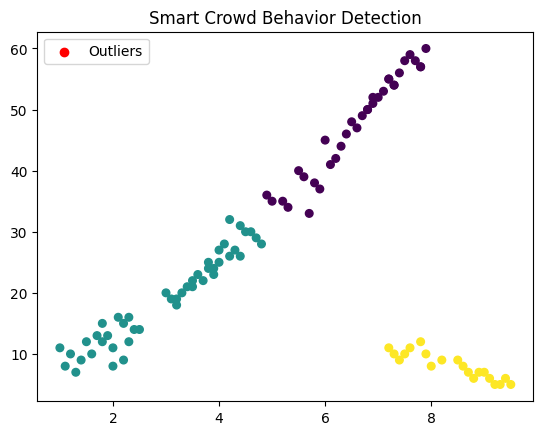

In [25]:
plt.scatter(data['speed'], data['time_spent'], c=data['cluster'], s=30)
plt.scatter(outliers['speed'], outliers['time_spent'], color='red', label='Outliers')
plt.legend()
plt.title("Smart Crowd Behavior Detection")
plt.show()